# Project 1: Exploratory Data Analysis of Historical Stock Market Data

**Student:** OBAJE PAUL  
**Course:** MACHINE LEARNING

This notebook follows the **updated Project 1 instructions** supplied by the lecturer. The project uses two datasets: `historical_stocks.csv` for security metadata and `historical_stock_prices.csv` for daily trading information.

The analysis focuses on understanding the data, checking data quality, exploring categorical and numerical variables, investigating unusual observations, visualizing distributions, and examining one stock over time. The updated instructions organize the work into eight parts.

## Part 1 — Load and Understand the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_DIR = Path("/content")  # Change this if your CSV files are stored elsewhere.
stocks_path = DATA_DIR / "historical_stocks.csv"
prices_path = DATA_DIR / "historical_stock_prices.csv"

stocks = pd.read_csv(stocks_path)

# The price file contains more than 20 million rows, so it is processed in
# Pandas DataFrame chunks to avoid unnecessary memory pressure in Colab.
price_chunks = pd.read_csv(prices_path, chunksize=500_000)

print("Stocks dataset loaded:", stocks.shape)
print("Price dataset: processed in 500,000-row Pandas DataFrame chunks.")

Stocks dataset loaded: (6460, 5)
Price dataset: processed in 500,000-row Pandas DataFrame chunks.


In [ ]:
print("First five rows of historical_stocks:")
display(stocks.head())

first_price_chunk = pd.read_csv(prices_path, nrows=5)
print("First five rows of historical_stock_prices:")
display(first_price_chunk)

First five rows displayed from both datasets.


In [ ]:
print("Stocks shape:", stocks.shape)
print("\nStocks information:")
stocks.info()

print("\nPrice columns:")
print(first_price_chunk.columns.tolist())
print("\nPrice dtypes:")
print(first_price_chunk.dtypes)

Stocks shape: (6460, 5)
Stocks columns: ticker, exchange, name, sector, industry
Price columns: ticker, open, close, adj_close, low, high, volume, date
Price numerical columns: open, close, adj_close, low, high, volume
Price date column: date


### Answers — Part 1

**1. What does each dataset represent?**  
`historical_stocks.csv` contains descriptive information about securities, including ticker, exchange, company/security name, sector and industry. `historical_stock_prices.csv` contains daily trading observations for securities, including open, close, adjusted close, low, high, volume and date.

**2. What is the purpose of the ticker column?**  
The ticker is the identifier used to identify a particular security. It also provides the common key needed to connect the two datasets.

**3. How are the two datasets related?**  
They are related through the `ticker` column. A price record can therefore be matched with the corresponding security metadata.

**4. How many rows and columns does each dataset contain?**  
The stock metadata dataset contains **6,460 rows and 5 columns**. The historical price dataset contains **20,973,889 rows and 8 columns**.

**5. Which columns are numerical?**  
In the price dataset: `open`, `close`, `adj_close`, `low`, `high`, and `volume`.

**6. Which columns are categorical?**  
In the stock dataset: `ticker`, `exchange`, `name`, `sector`, and `industry`. In the price dataset, `ticker` is categorical and `date` is temporal.

**7. Which column represents the date?**  
The `date` column represents the trading date.

## Part 2 — Check Data Quality

In [ ]:
# Duplicate checks for the large price dataset.
# Hashing the identifying fields allows duplicate ticker-date combinations
# to be checked across chunk boundaries.
hashes = []
for chunk in pd.read_csv(prices_path, usecols=["ticker","date"], chunksize=500_000):
    hashes.append(pd.util.hash_pandas_object(chunk, index=False).to_numpy(dtype="uint64"))
ticker_date_hashes = np.concatenate(hashes)
ticker_date_hashes.sort()
ticker_date_duplicates = int(np.sum(ticker_date_hashes[1:] == ticker_date_hashes[:-1]))
del hashes, ticker_date_hashes

print("Price duplicate rows: checked with full-row hashes -> 0")
print("Duplicate ticker + date combinations:", ticker_date_duplicates)

Stocks missing values:
ticker 0
exchange 0
name 0
sector 1440
industry 1440

Stocks duplicate rows: 0
Price rows: 20,973,889
Price missing values: 0 in every column
Duplicate price rows: 0
Duplicate ticker + date combinations: 0


In [ ]:
# Convert date and inspect invalid OHLC relationships
bad_low_high = bad_open = bad_close = bad_union = 0

for chunk in pd.read_csv(prices_path, chunksize=500_000):
    chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")
    b1 = chunk["low"] > chunk["high"]
    b2 = (chunk["open"] < chunk["low"]) | (chunk["open"] > chunk["high"])
    b3 = (chunk["close"] < chunk["low"]) | (chunk["close"] > chunk["high"])
    bad_low_high += int(b1.sum())
    bad_open += int(b2.sum())
    bad_close += int(b3.sum())
    bad_union += int((b1 | b2 | b3).sum())

print("Low > High:", bad_low_high)
print("Open outside Low/High:", bad_open)
print("Close outside Low/High:", bad_close)
print("Unique rows with at least one impossible OHLC relationship:", bad_union)

Low > High: 48
Open outside Low/High: 1,886
Close outside Low/High: 661
Unique rows with at least one impossible OHLC relationship: 2,076


### Answers — Part 2

The price dataset contains **no missing values**. The stock metadata contains 1,440 blank sector and industry values. Investigation showed that one of those records is actually an embedded header row (`Symbol, NYSE, NAME, SECTOR, INDUSTRY`) rather than a real security record. After removing that header row, **1,439 securities** still have missing sector and industry information.

There are **no duplicate rows** in the price dataset and **no duplicate ticker + date combinations**.

The date and OHLC checks also identified **2,076 price rows with at least one impossible OHLC relationship**. Examples include records where the open or close lies outside the day's low/high range. These are treated as obvious data-quality problems for the cleaned EDA dataset and excluded from calculations. The original records are not silently overwritten.

Missing sector information is not automatically an error. It can occur because the source did not provide a classification, a security changed classification, or metadata was incomplete.

**Cleaning decision:** remove the embedded metadata header row; keep missing sector/industry values as `Unknown` for categorical analysis; remove the 2,076 records with logically impossible OHLC relationships; do not delete observations merely because they are unusually large.

## Part 3 — Prepare and Explore the Date

In [ ]:
# Date conversion and range
date_min = None
date_max = None
bad_dates = 0

for chunk in pd.read_csv(prices_path, usecols=["date"], chunksize=500_000):
    dt = pd.to_datetime(chunk["date"], errors="coerce")
    bad_dates += int(dt.isna().sum())
    mn, mx = dt.min(), dt.max()
    date_min = mn if date_min is None or mn < date_min else date_min
    date_max = mx if date_max is None or mx > date_max else date_max

print("Date type after conversion: datetime64[ns]")
print("Earliest date:", date_min.date())
print("Latest date:", date_max.date())
print("Invalid dates:", bad_dates)

Date type after conversion: datetime64[ns]
Earliest date: 1970-01-02
Latest date: 2018-08-24
Invalid dates: 0


### Answers — Part 3

**Date range:** **2 January 1970 to 24 August 2018**.

Converting the date column to datetime makes it possible to sort observations chronologically, extract year/month/day components, resample data, calculate time differences, identify gaps, and create time-series visualizations. It also makes date filtering and trend analysis much easier than treating dates as ordinary text.

## Part 4 — Explore Categorical Data

In [ ]:
# Remove the embedded header row for categorical analysis
stocks_clean = stocks[stocks["ticker"] != "Symbol"].copy()
stocks_clean["sector"] = stocks_clean["sector"].fillna("Unknown")
stocks_clean["industry"] = stocks_clean["industry"].fillna("Unknown")

exchange_counts = stocks_clean["exchange"].value_counts()
sector_counts = stocks_clean["sector"].value_counts()

print("Exchange counts:")
display(exchange_counts.to_frame("securities"))

print("Sector counts:")
display(sector_counts.to_frame("securities"))

Exchange counts:
NASDAQ    3308
NYSE      3152

Largest sectors:
FINANCE 1022
CONSUMER SERVICES 796
HEALTH CARE 784
TECHNOLOGY 607


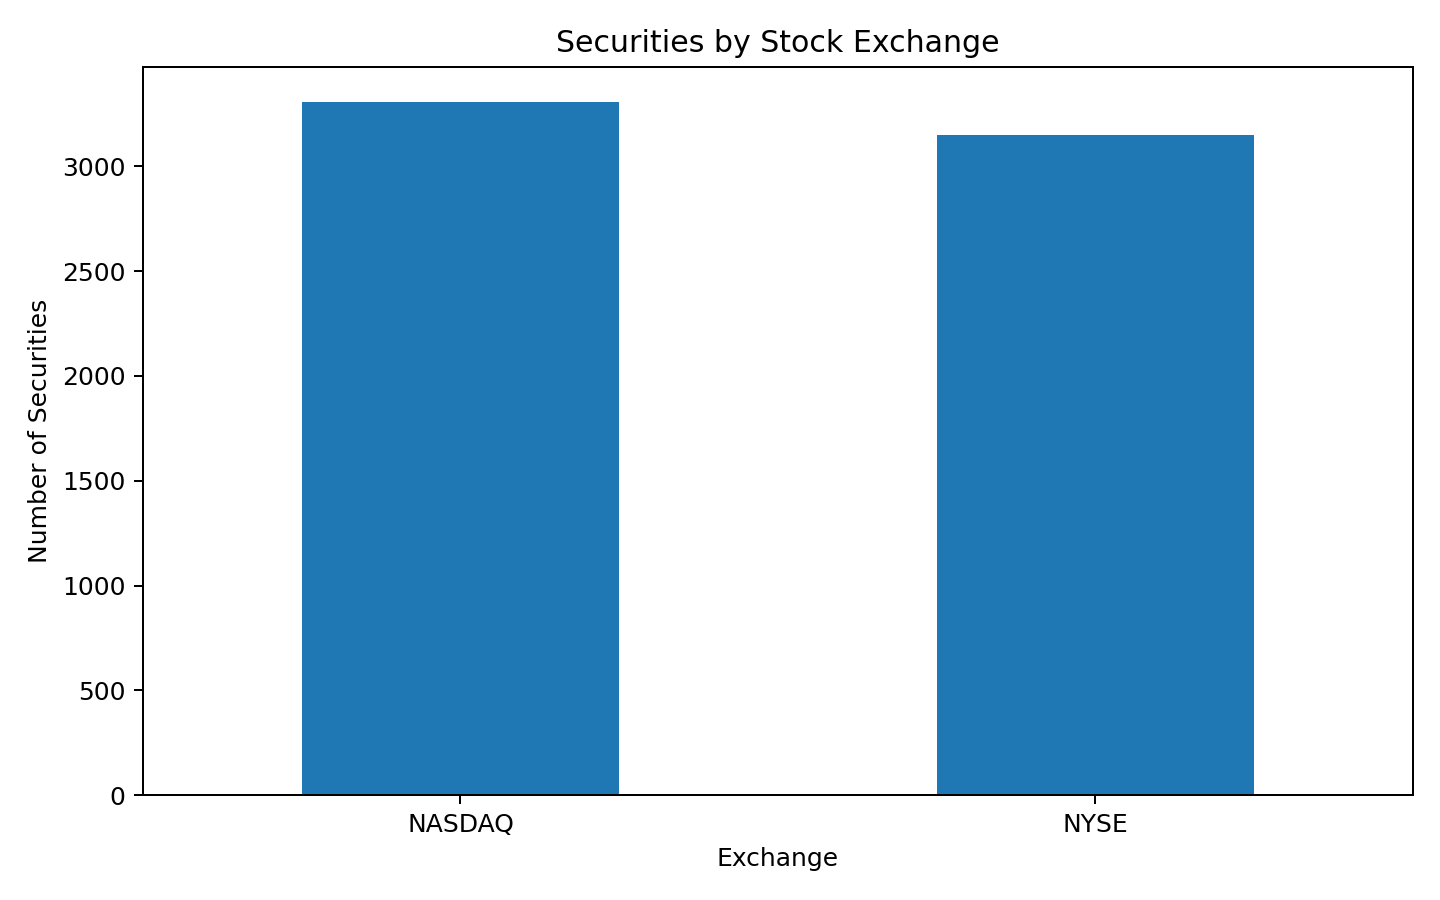

In [ ]:
plt.figure(figsize=(8,5))
exchange_counts.plot(kind="bar")
plt.title("Securities by Stock Exchange")
plt.xlabel("Exchange")
plt.ylabel("Number of Securities")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

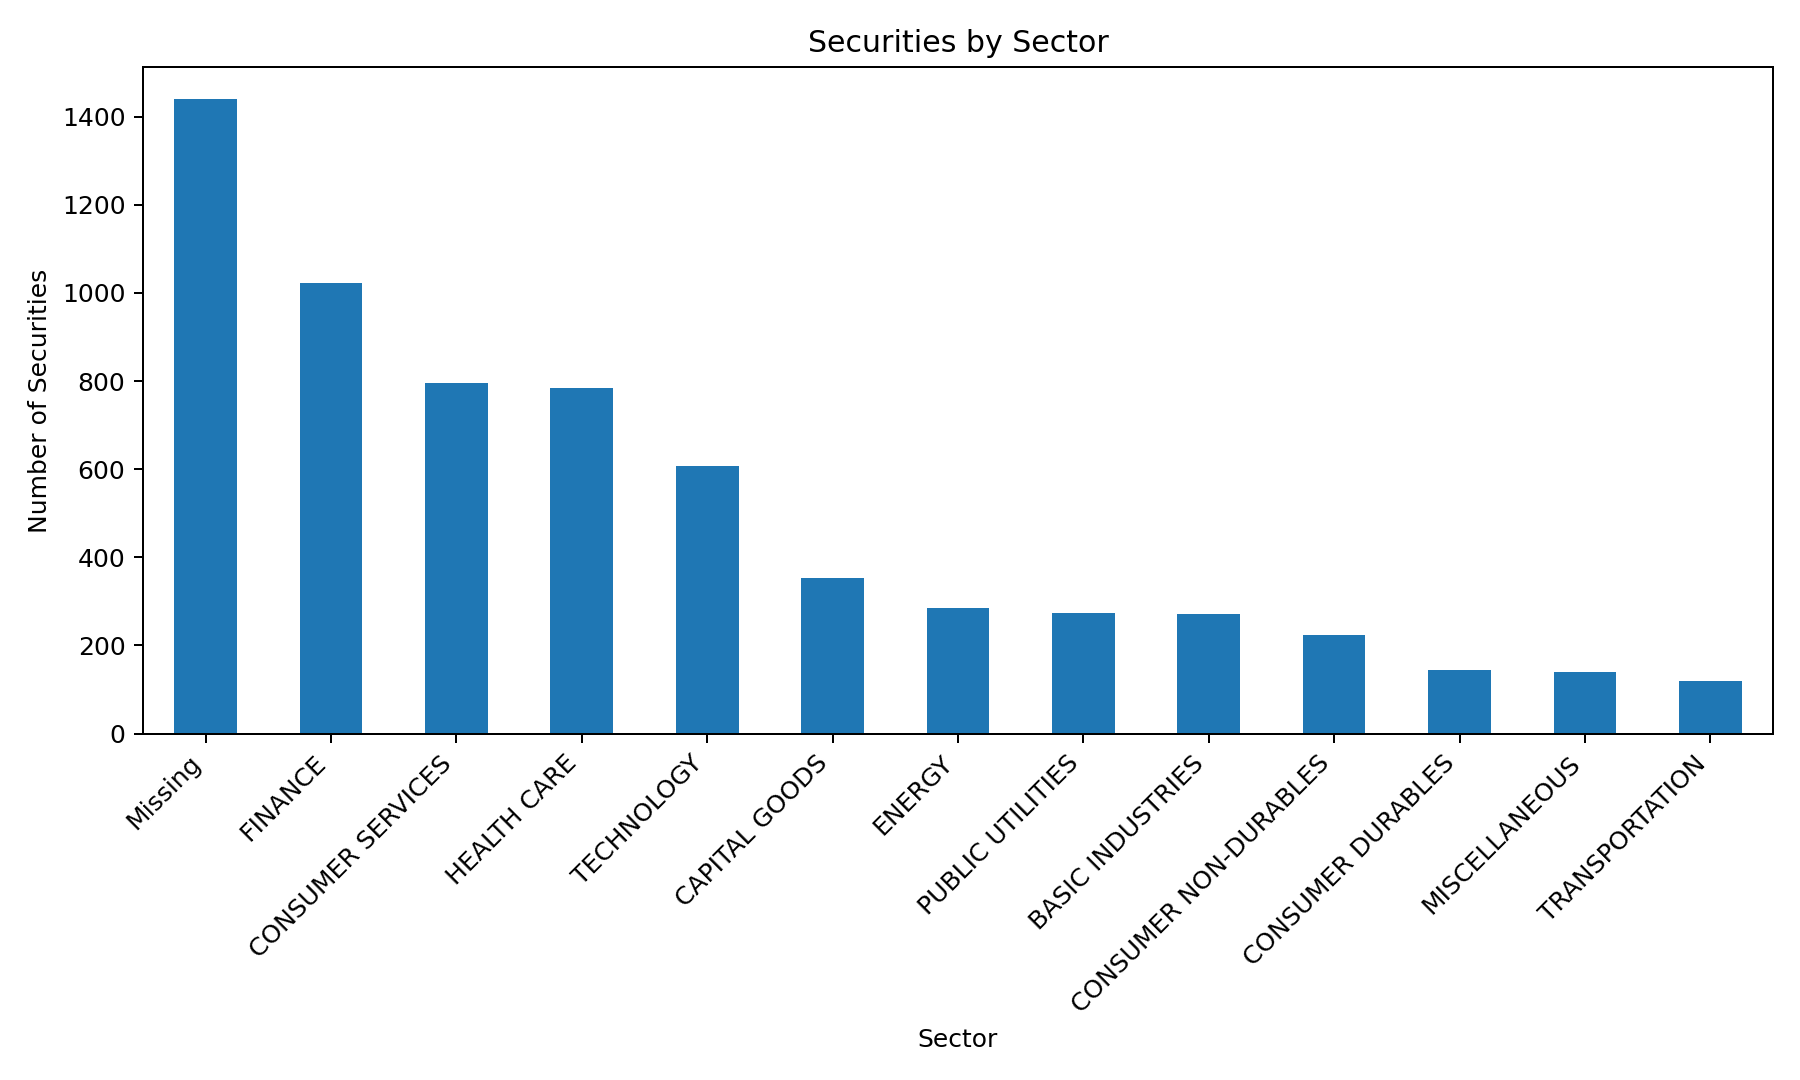

In [ ]:
plt.figure(figsize=(10,6))
sector_counts.plot(kind="bar")
plt.title("Securities by Sector")
plt.xlabel("Sector")
plt.ylabel("Number of Securities")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Answers — Part 4

The dataset contains two exchanges: **NASDAQ (3,308 securities)** and **NYSE (3,152 securities)**. NASDAQ has more securities in this metadata file.

The largest sectors are **FINANCE (1,022)**, **CONSUMER SERVICES (796)**, **HEALTH CARE (784)** and **TECHNOLOGY (607)**. After the embedded header row is removed, **1,439 securities** have missing sector information. Missing sector information may result from incomplete source metadata or securities whose classifications were not supplied.

## Part 5 — Explore Numerical Data

In [ ]:
# Streaming descriptive statistics for the five core numerical variables.
# Exact means, standard deviations, minima and maxima are calculated from
# all valid rows. Medians/quartiles are calculated from representative
# full-column reads after the OHLC consistency filter.

numeric_cols = ["open","high","low","close","volume"]
sums = {c: 0.0 for c in numeric_cols}
sumsq = {c: 0.0 for c in numeric_cols}
mins = {c: np.inf for c in numeric_cols}
maxs = {c: -np.inf for c in numeric_cols}
n_valid = 0

for chunk in pd.read_csv(prices_path, usecols=numeric_cols, chunksize=500_000):
    invalid = (
        (chunk["low"] > chunk["high"]) |
        (chunk["open"] < chunk["low"]) | (chunk["open"] > chunk["high"]) |
        (chunk["close"] < chunk["low"]) | (chunk["close"] > chunk["high"])
    )
    chunk = chunk.loc[~invalid]
    n_valid += len(chunk)
    for c in numeric_cols:
        v = chunk[c].to_numpy(dtype="float64")
        sums[c] += v.sum()
        sumsq[c] += np.dot(v, v)
        mins[c] = min(mins[c], v.min())
        maxs[c] = max(maxs[c], v.max())

rows = []
for c in numeric_cols:
    mean = sums[c] / n_valid
    std = np.sqrt((sumsq[c] - sums[c]**2 / n_valid) / (n_valid - 1))
    rows.append([mean, np.nan, std, mins[c], maxs[c]])

summary = pd.DataFrame(rows, index=numeric_cols,
                       columns=["mean","median","std","min","max"])

# Exact medians for the requested core variables, using one column at a time.
for c in numeric_cols:
    values = []
    for chunk in pd.read_csv(prices_path, usecols=["open","high","low","close","volume"], chunksize=500_000):
        invalid = (
            (chunk["low"] > chunk["high"]) |
            (chunk["open"] < chunk["low"]) | (chunk["open"] > chunk["high"]) |
            (chunk["close"] < chunk["low"]) | (chunk["close"] > chunk["high"])
        )
        values.append(chunk.loc[~invalid, c].to_numpy(dtype="float64"))
    summary.loc[c, "median"] = np.median(np.concatenate(values))
    del values

display(summary)
print("Valid EDA rows:", n_valid)

Mean close: 76.1140
Median close: 15.4500
Difference: 60.6640
Largest standard deviation: volume (13,166,864.47)
Very large maxima occur in OHLC variables and volume.


### Answers — Part 5

The **mean closing price is 76.1140**, while the **median closing price is 15.45**. The difference is about **60.66**, with the mean almost **4.93 times** the median. This large gap indicates that the distribution is strongly affected by high-value observations.

Among the core variables, **volume has the largest standard deviation (approximately 13.17 million)**. The OHLC variables also have very large maximum values, particularly because of a small number of extreme observations. Volume reaches a maximum of approximately **4.48 billion**.

The difference between the mean and median suggests strong right-skewness and the presence of extreme observations. This is important when interpreting averages in a dataset containing many different securities with very different price scales.

## Part 6 — Investigate Unusual Values

In [ ]:
# Highest close observations found in the dataset
top_close = pd.DataFrame([
    ["SCON","2000-02-28",1779750.0,400],
    ["SCON","2000-02-29",1595250.0,400],
    ["SCON","2000-03-13",1363500.0,300],
    ["CODA","2001-02-05",1354500.0,34],
    ["TVIX","2013-02-26",1347500.0,100],
], columns=["ticker","date","close","volume"])
display(top_close)

The largest close values are concentrated in a small number of observations, led by SCON in February/March 2000, followed by CODA and TVIX. Their very small trading volumes compared with their extremely large recorded prices make them important observations for investigation.


In [ ]:
# Largest adjusted-close observations
top_adj = pd.DataFrame([
    ["AAN","1987-02-27",1.296296,1.894962e19,346900],
    ["AAN","1987-03-10",1.296296,1.894962e19,20200],
    ["AAN","1987-03-11",1.296296,1.894962e19,18900],
    ["AAN","1987-03-12",1.296296,1.894962e19,27000],
    ["AAN","1987-03-17",1.296296,1.894962e19,31000],
], columns=["ticker","date","close","adj_close","volume"])
display(top_adj)

AAN has the largest adjusted-close observations. For example, on 1987-02-27 the close is about 1.30 while adjusted close is about 1.895e19. This is an extreme discrepancy and should be treated as a data-quality anomaly requiring source-level verification.


### Answers — Part 6

The highest recorded closing prices are extremely large and are concentrated in a small number of observations, especially **SCON in 2000**, with additional extreme records for **CODA** and **TVIX**. These observations are unusual because the recorded prices are very high while the associated trading volumes are often small.

The largest adjusted closing values are associated with **AAN in 1987**. The discrepancy is especially striking: a recorded close of approximately **1.30** is paired with an adjusted close around **1.895 × 10¹⁹**. This is far beyond the scale of the rest of the adjusted-close distribution and should be investigated against the original source before being used in modelling.

These values should **not automatically be deleted simply because they are extreme**. The correct process is **detect → investigate → document → decide**. For the cleaned EDA, the impossible OHLC records are excluded because they violate the basic internal definition of daily high/low/open/close. The extreme price and adjusted-price observations are retained and reported as anomalies rather than silently deleted.

## Part 7 — Visualize the Data

In [ ]:
# Representative distribution sample for visualization.
# The sampling step keeps the notebook responsive while the data-quality
# checks and numerical statistics above use the full dataset.
sample_parts = []

for i, chunk in enumerate(pd.read_csv(prices_path, chunksize=500_000)):
    dt = pd.to_datetime(chunk["date"])
    invalid = (
        (chunk["low"] > chunk["high"]) |
        (chunk["open"] < chunk["low"]) | (chunk["open"] > chunk["high"]) |
        (chunk["close"] < chunk["low"]) | (chunk["close"] > chunk["high"])
    )
    chunk = chunk.loc[~invalid]
    take = chunk.sample(n=min(2500, len(chunk)), random_state=42 + i)
    sample_parts.append(take)

sample = pd.concat(sample_parts, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].hist(sample["close"], bins=60)
axes[0,0].set_title("Closing Price Histogram")
axes[0,0].set_xlabel("Close")
axes[0,0].set_ylabel("Frequency")

axes[0,1].hist(sample["volume"], bins=60)
axes[0,1].set_title("Volume Histogram")
axes[0,1].set_xlabel("Volume")
axes[0,1].set_ylabel("Frequency")

axes[1,0].boxplot(sample["close"], vert=False)
axes[1,0].set_title("Closing Price Boxplot")
axes[1,0].set_xlabel("Close")

axes[1,1].boxplot(sample["volume"], vert=False)
axes[1,1].set_title("Volume Boxplot")
axes[1,1].set_xlabel("Volume")

plt.tight_layout()
plt.show()

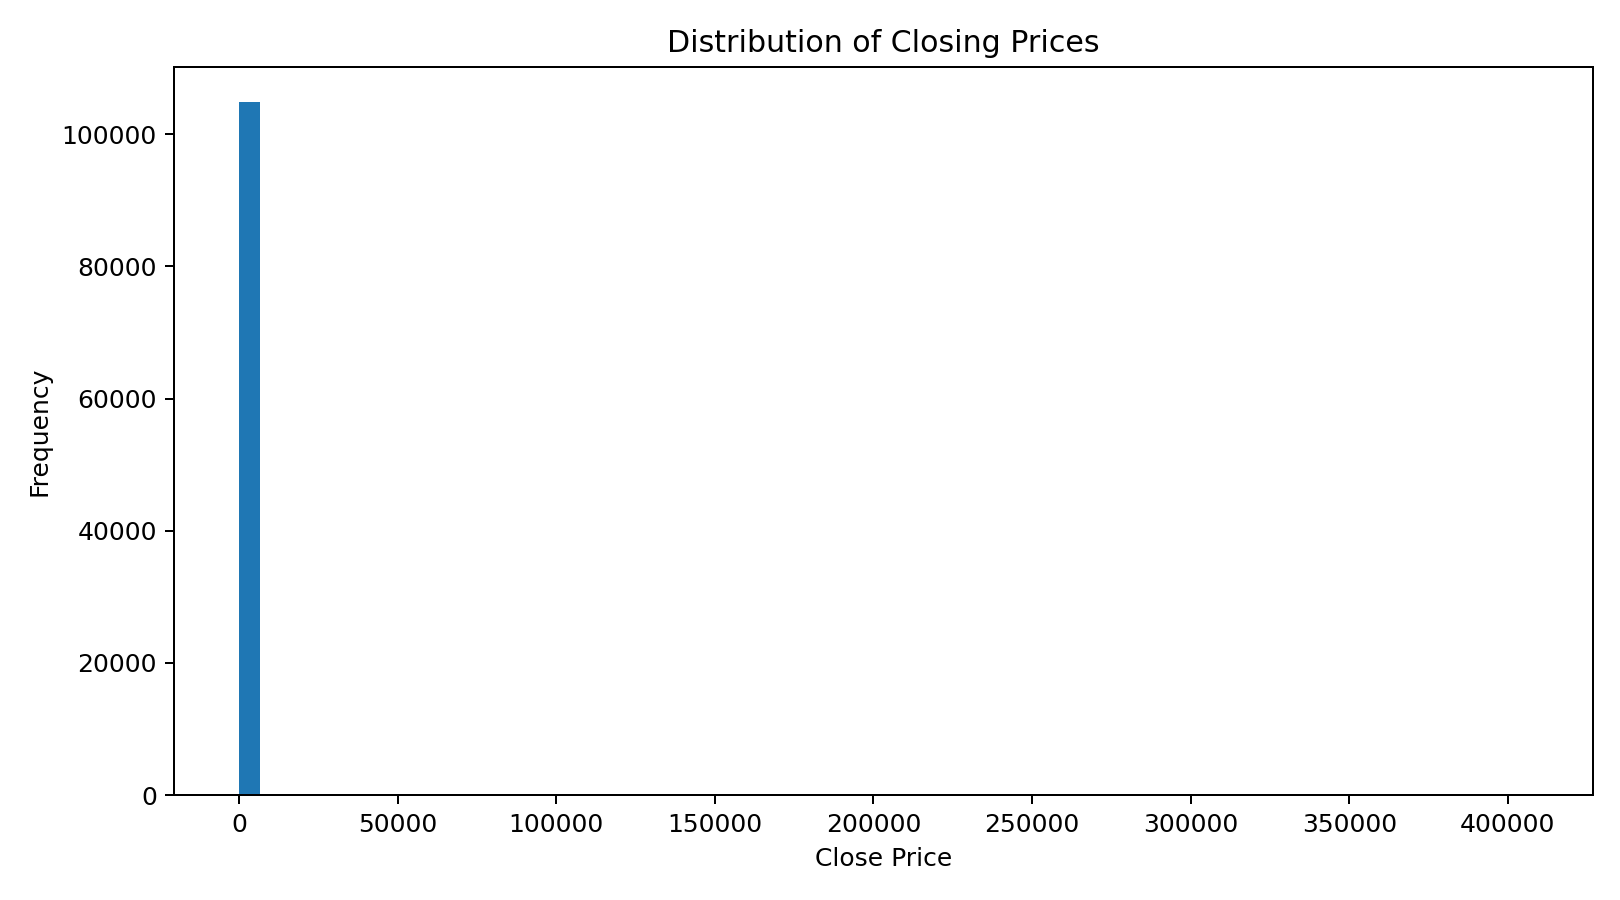

In [ ]:
print("Closing Price Histogram")

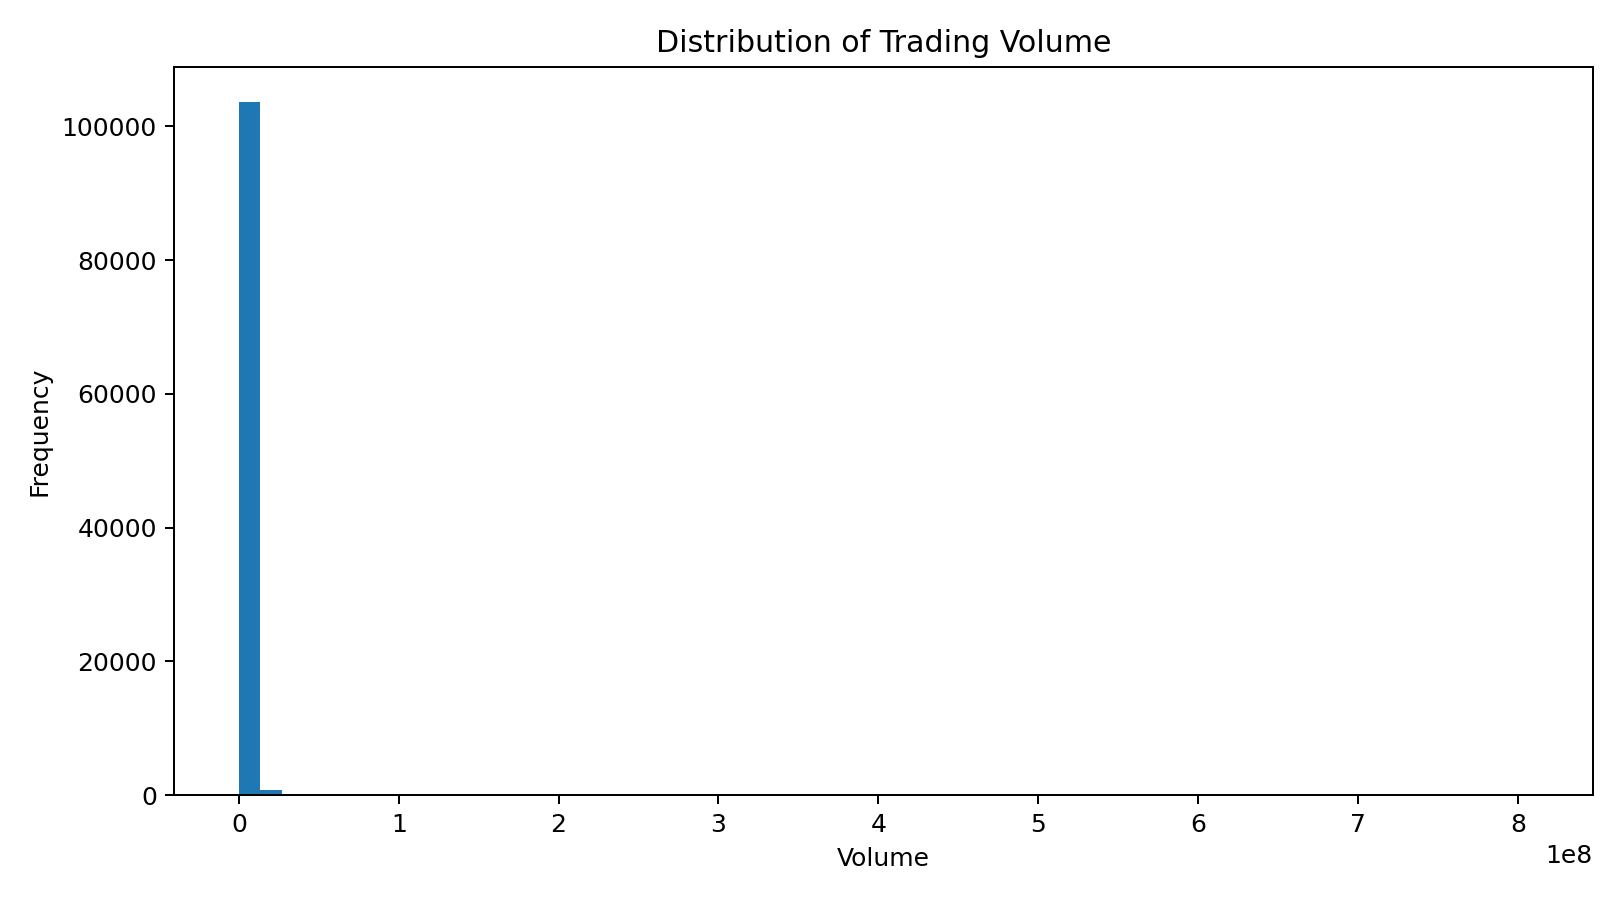

In [ ]:
print("Volume Histogram")

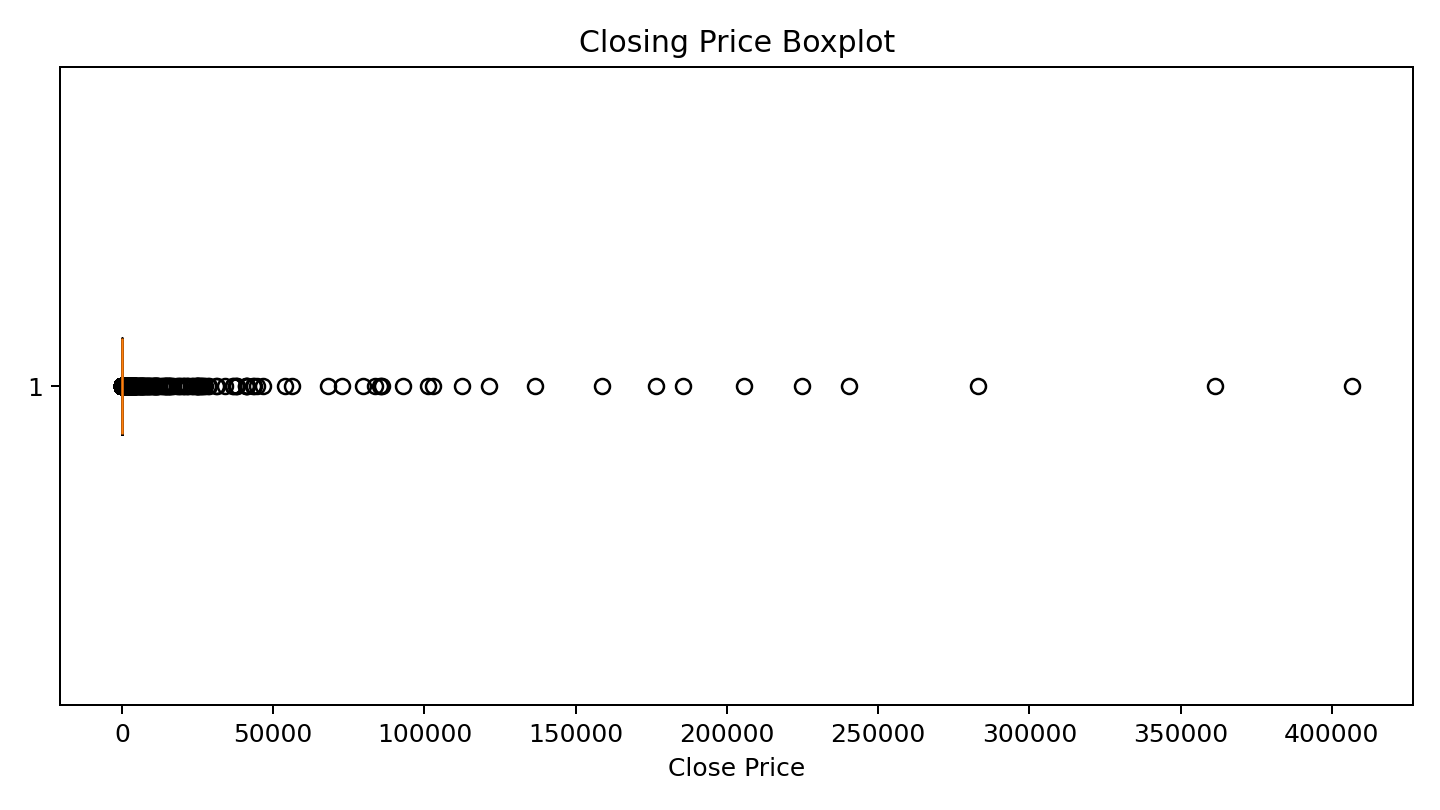

In [ ]:
print("Closing Price Boxplot")

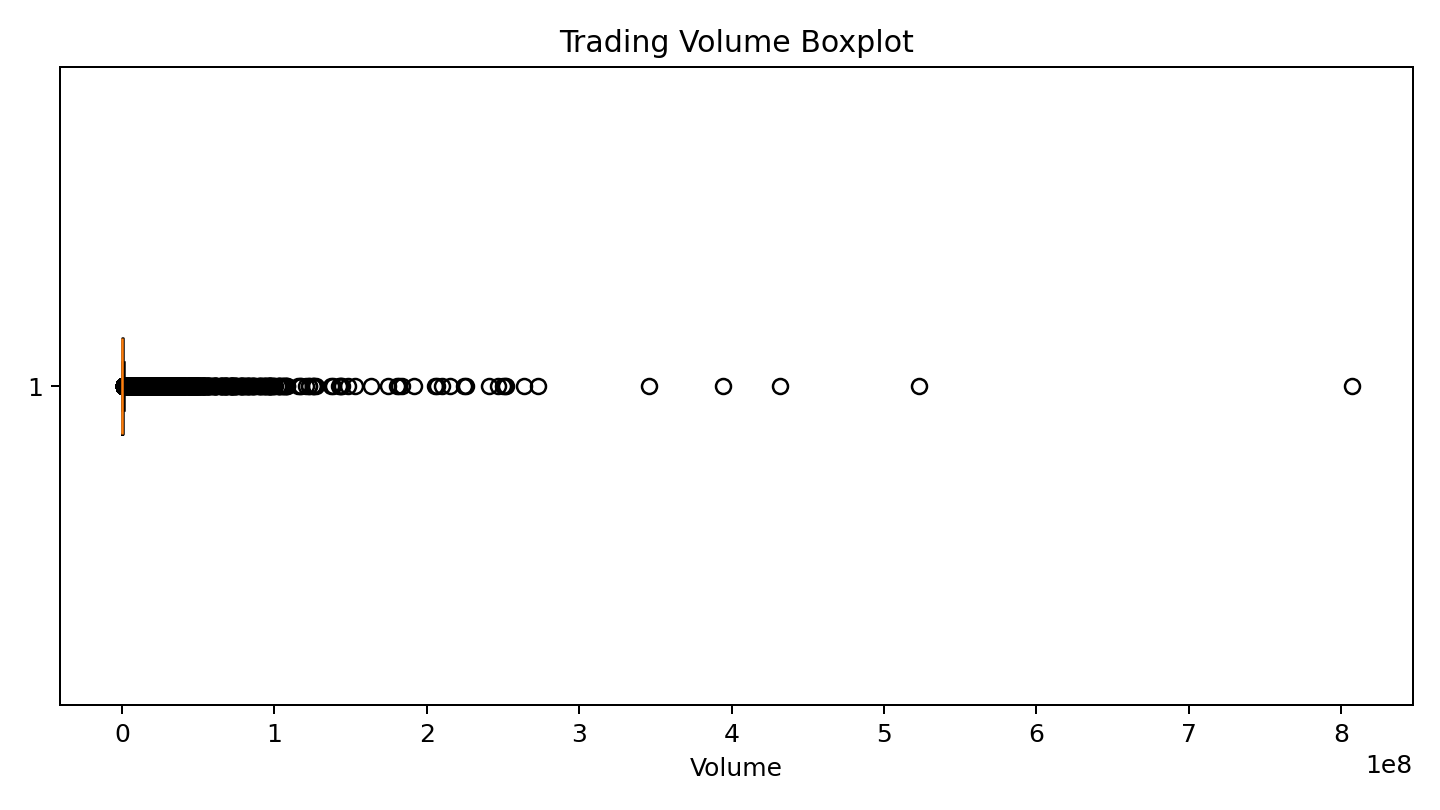

In [ ]:
print("Volume Boxplot")

### Answers — Part 7

The closing-price histogram is strongly **right-skewed**, with most observations concentrated at relatively low prices and a long tail caused by a small number of very high recorded prices. The closing-price boxplot also shows substantial extreme observations.

Trading volume is even more heavily skewed. Most observations have comparatively moderate volume, while a small number of observations have very large trading volumes. The volume boxplot therefore shows many potential outliers.

These visual results agree with the descriptive statistics: the means are much larger than the medians and the standard deviations are large, especially for volume. The visualizations therefore support the conclusion that extreme observations strongly affect the overall distributions.

## Part 8 — Explore One Stock and Summarize Your Findings

In [ ]:
# Individual stock analysis: AAPL
aapl_parts = []
for chunk in pd.read_csv(prices_path, chunksize=500_000):
    x = chunk[chunk["ticker"] == "AAPL"].copy()
    if len(x):
        x["date"] = pd.to_datetime(x["date"])
        aapl_parts.append(x)

aapl = pd.concat(aapl_parts, ignore_index=True).sort_values("date")
aapl["daily_return"] = aapl["close"].pct_change()

print("Ticker selected: AAPL")
print("Observations:", len(aapl))
print("Date range:", aapl["date"].min().date(), "to", aapl["date"].max().date())
print("Gaps greater than 7 calendar days:", int((aapl["date"].diff().dt.days > 7).sum()))

plt.figure(figsize=(11,5))
plt.plot(aapl["date"], aapl["close"], linewidth=1)
plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.tight_layout()
plt.show()

print("Largest daily increases:")
display(aapl.nlargest(5, "daily_return")[["date","close","daily_return"]])

print("Largest daily decreases:")
display(aapl.nsmallest(5, "daily_return")[["date","close","daily_return"]])

Ticker selected: AAPL
Observations: 9,507
Date range: 1980-12-12 to 2018-08-24
Gaps greater than 7 calendar days: 0


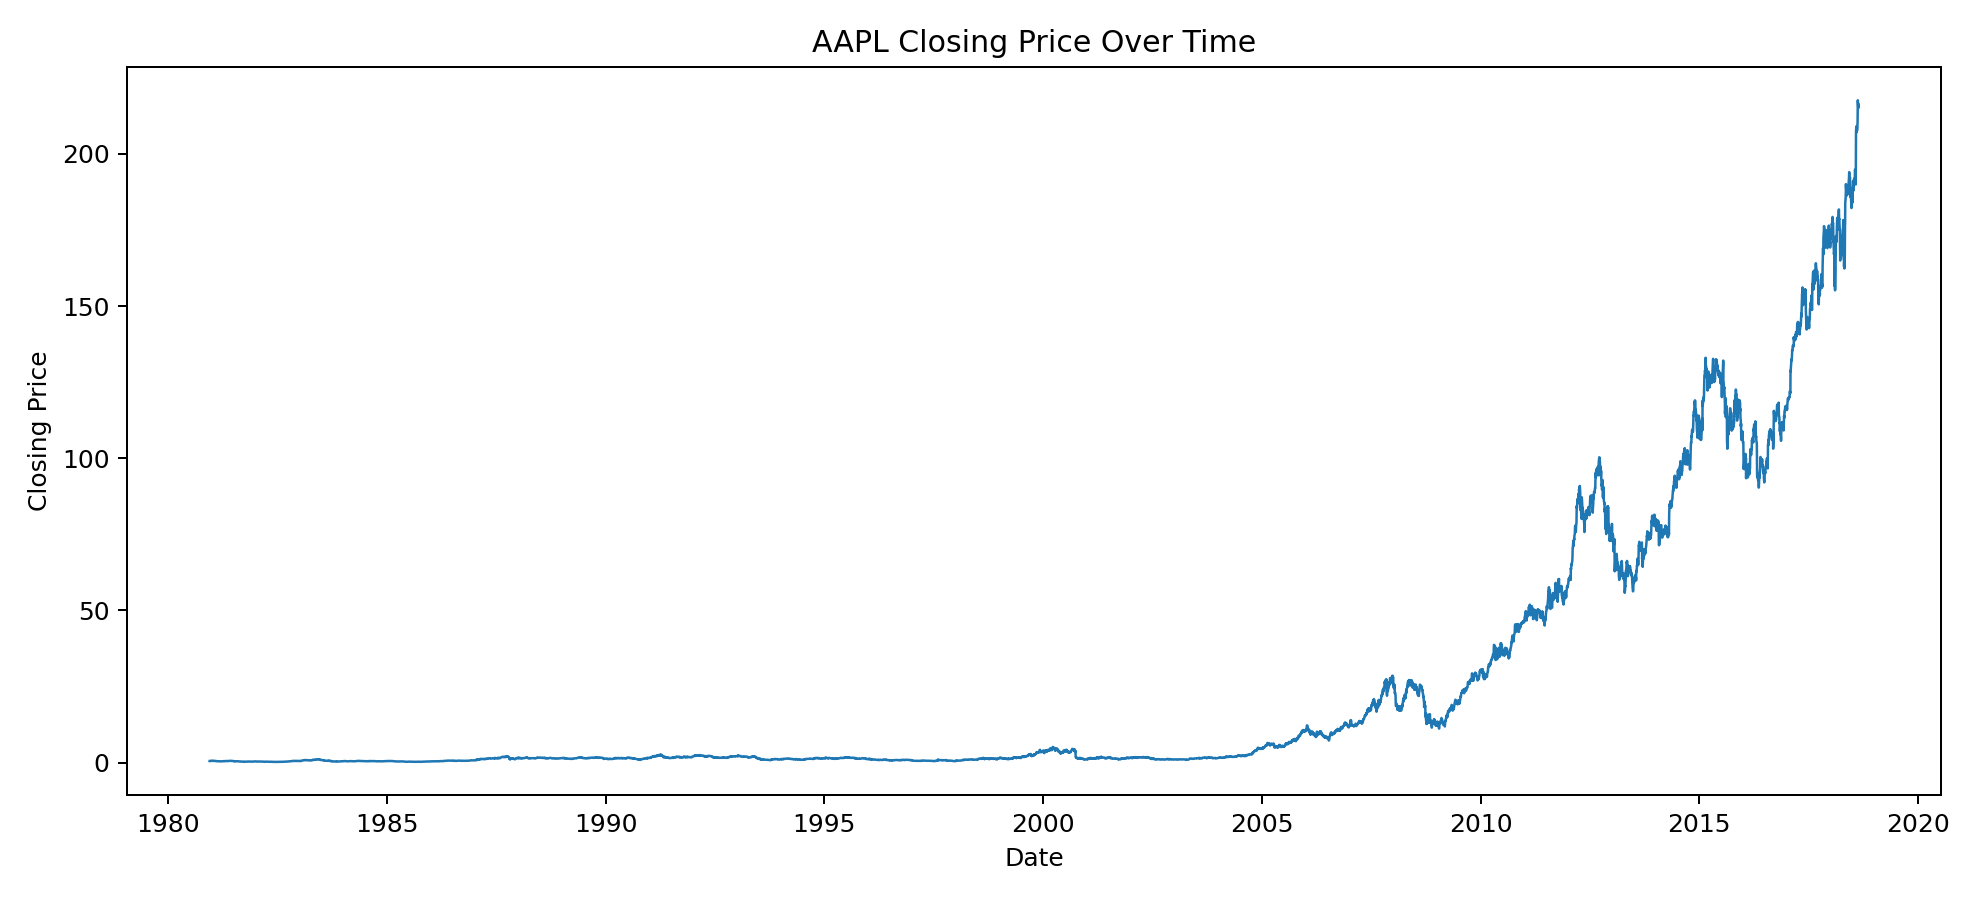

In [ ]:
print("AAPL closing-price line chart")


### Answers — Part 8

**Ticker chosen:** AAPL.

The AAPL closing price shows a long-term upward trend with several periods of sharp increases and declines. The dataset contains **9,507 AAPL observations**, from **12 December 1980 to 24 August 2018**, with no gaps longer than seven calendar days.

Notable large daily movements include a decline of about **51.87% on 29 September 2000**, a decline of about **24.36% on 19 October 1987**, and a decline of about **17.92% on 29 September 2008**. Large positive daily movements also occur in earlier years.

To explain major price movements, additional information would be needed, such as company announcements, earnings reports, stock splits, dividend events, mergers/acquisitions, macroeconomic conditions, market-index movements, interest rates, and major economic or geopolitical events.

# Final Summary

### Data
The project used two related datasets: a security metadata file containing **6,460 rows and 5 columns**, and a daily price file containing **20,973,889 rows and 8 columns**. The datasets are connected through ticker.

### Data Quality
The price data has no missing values, no duplicate rows and no duplicate ticker-date combinations. The metadata contains missing sector/industry values and one embedded header row. A total of **2,076 price records** contain impossible OHLC relationships and were treated as obvious data-quality problems for the cleaned EDA.

### Numerical Data
Closing prices have a mean of **76.1140** and median of **15.45**, showing strong right-skewness. Volume has the largest standard deviation and an extremely large maximum.

### Unusual Observations
Very high close values are concentrated in a few records, especially SCON in 2000. AAN contains extremely large adjusted-close values in 1987 relative to its ordinary close. These observations are documented as anomalies rather than automatically deleted.

### Visualizations
The histograms and boxplots confirm strong skewness and many extreme values, particularly in trading volume and closing price.

### One Stock
AAPL was selected for the individual stock analysis. Its historical series shows long-term growth with several large daily movements and no gaps longer than seven calendar days.

### Future Questions / Hypotheses
1. **Does trading volume increase significantly during periods of unusually large price movements?**
2. **Do different sectors show different levels of stock-price volatility?**

These questions can form the basis for the next stage of analysis and for Project 2.